# Prophet Forecasting for Campus Waste Intelligence

This notebook builds separate Prophet models for each canteen section (A, B, C, D) using pre-defined hyperparameters.

**Workflow:**

1. Load and explore the waste dataset.
2. Chronological train / validation / test split (global cutoffs).
3. Train Prophet models with given hyperparameters and regressors (`Foot_Traffic`, `is_holiday`, `is_special_day`).
4. Evaluate models on validation and test sets (MAPE, RMSE, MAE, R²).
5. Visualise actual vs predicted on test set.
6. Generate and plot 7‑day forecasts for all sections.
7. Save trained models as joblib files.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Change working directory to project folder
import os
try:
    os.chdir("/content/drive/MyDrive/UAB/FDS/campus-waste-intelligence")
    print("Directory changed successfully")
except OSError:
    print("Error: Can't change the Current Working Directory")

Mounted at /content/drive
Directory changed successfully


## 1. Load Dataset

The dataset is expected to be named `waste_data.csv`. Adjust the filename if necessary.

In [3]:
# Load the dataset
df = pd.read_csv('data/food_waste_features.csv', parse_dates=['time_bin'])

# Convert time_bin to datetime and sort
df['time_bin'] = pd.to_datetime(df['time_bin'])
df = df.sort_values('time_bin').reset_index(drop=True)

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Canteen sections: {df['Canteen_Section'].unique()}")
print("\nFirst few rows:")
print(df.head())

# Check date range
print(f"\nDate range: {df['time_bin'].min()} to {df['time_bin'].max()}")

Raw shape: (99700, 7)
Columns: ['Canteen_Section', 'time_bin', 'Waste_Weight_kg', 'Cost_Loss', 'Foot_Traffic', 'is_holiday', 'is_special_day']
Canteen sections: ['D' 'C' 'A' 'B']

First few rows:
  Canteen_Section            time_bin  Waste_Weight_kg  Cost_Loss  Foot_Traffic  is_holiday  is_special_day
0               D 2015-01-01 06:00:00            0.010       0.02          0.56           1               1
1               C 2015-01-01 06:30:00            0.024       0.19          0.06           1               1
2               A 2015-01-01 07:00:00            0.090       0.14          1.20           1               1
3               B 2015-01-01 07:30:00            0.020       0.16          1.80           1               1
4               A 2015-01-01 08:00:00            0.007       0.06          0.07           1               1

Date range: 2015-01-01 06:00:00 to 2025-08-10 19:30:00


## 2. Chronological Train / Validation / Test Split

We define global cutoffs based on the overall date range so that all sections share the same split points. This prevents future data leakage.

Proportions: 70% train, 15% validation, 15% test.

In [4]:
# Get global sorted unique timestamps
all_dates = df['time_bin'].sort_values().unique()
n = len(all_dates)

# Compute cutoffs
train_cutoff = all_dates[int(0.7 * n)]
val_cutoff   = all_dates[int(0.85 * n)]

print(f"Train cutoff  : {train_cutoff}")
print(f"Validation cutoff: {val_cutoff}")
print(f"Test cutoff   : {all_dates[-1]}")

# Create split masks for each section
sections = df['Canteen_Section'].unique()
train_data = {}
val_data   = {}
test_data  = {}

for sec in sections:
    sec_df = df[df['Canteen_Section'] == sec].copy()
    train_data[sec] = sec_df[sec_df['time_bin'] <= train_cutoff]
    val_data[sec]   = sec_df[(sec_df['time_bin'] > train_cutoff) & (sec_df['time_bin'] <= val_cutoff)]
    test_data[sec]  = sec_df[sec_df['time_bin'] > val_cutoff]

print("\nSplit sizes per section:")
for sec in sections:
    print(f"{sec}: Train={len(train_data[sec])}, Val={len(val_data[sec])}, Test={len(test_data[sec])}")

Train cutoff  : 2022-06-05 12:30:00
Validation cutoff: 2024-01-07 17:30:00
Test cutoff   : 2025-08-10 19:30:00

Split sizes per section:
D: Train=17557, Val=3763, Test=3715
C: Train=17224, Val=3629, Test=3672
A: Train=17359, Val=3601, Test=3710
B: Train=17749, Val=3855, Test=3866


## 3. Hyperparameters Definition

As provided, each section has its own set of Prophet parameters. We also define the regressors to be used (foot traffic, holiday flags).

In [5]:
params_per_section = {
    "A": {
        "changepoint_prior_scale": 0.25,
        "seasonality_prior_scale": 3.0,
        "seasonality_mode": "additive",
        "regressor_prior": 0.5
    },
    "B": {
        "changepoint_prior_scale": 0.3,
        "seasonality_prior_scale": 3.0,
        "seasonality_mode": "additive",
        "regressor_prior": 0.5
    },
    "C": {
        "changepoint_prior_scale": 0.2,
        "seasonality_prior_scale": 3.0,
        "seasonality_mode": "additive",
        "regressor_prior": 0.5
    },
    "D": {
        "changepoint_prior_scale": 0.3,
        "seasonality_prior_scale": 3.0,
        "seasonality_mode": "additive",
        "regressor_prior": 0.5
    },
}

regressor_list = ['Foot_Traffic', 'is_holiday', 'is_special_day']
print("Regressors used:", regressor_list)

Regressors used: ['Foot_Traffic', 'is_holiday', 'is_special_day']


## 4. Train Prophet Models

For each section:
- Prepare training data (ds = time_bin, y = Waste_Weight_kg)
- Instantiate Prophet with section-specific parameters
- Add regressors with `prior_scale` = regressor_prior from parameters
- Fit model

We store the trained models in a dictionary.

In [6]:
models = {}

for sec in sections:
    print(f"\n{'='*50}")
    print(f"Training model for section {sec}")
    print(f"Parameters: {params_per_section[sec]}")

    # Prepare training dataframe
    train_df = train_data[sec][['time_bin', 'Waste_Weight_kg'] + regressor_list].rename(
        columns={'time_bin': 'ds', 'Waste_Weight_kg': 'y'}
    )

    # Create Prophet model
    model = Prophet(
        changepoint_prior_scale=params_per_section[sec]['changepoint_prior_scale'],
        seasonality_prior_scale=params_per_section[sec]['seasonality_prior_scale'],
        seasonality_mode=params_per_section[sec]['seasonality_mode'],
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )

    # Add regressors
    for reg in regressor_list:
        model.add_regressor(reg, prior_scale=params_per_section[sec]['regressor_prior'])

    # Fit
    model.fit(train_df)
    models[sec] = model
    print(f"Model for section {sec} trained successfully.")


Training model for section D
Parameters: {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 3.0, 'seasonality_mode': 'additive', 'regressor_prior': 0.5}
Model for section D trained successfully.

Training model for section C
Parameters: {'changepoint_prior_scale': 0.2, 'seasonality_prior_scale': 3.0, 'seasonality_mode': 'additive', 'regressor_prior': 0.5}
Model for section C trained successfully.

Training model for section A
Parameters: {'changepoint_prior_scale': 0.25, 'seasonality_prior_scale': 3.0, 'seasonality_mode': 'additive', 'regressor_prior': 0.5}
Model for section A trained successfully.

Training model for section B
Parameters: {'changepoint_prior_scale': 0.3, 'seasonality_prior_scale': 3.0, 'seasonality_mode': 'additive', 'regressor_prior': 0.5}
Model for section B trained successfully.


## 5. Evaluate on Validation Set

We predict waste weight for the validation period using the trained models and compute error metrics: MAPE, RMSE, MAE, R².

In [7]:
def compute_metrics(y_true, y_pred):
    """Compute MAPE, RMSE, MAE, R²."""
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mape, rmse, mae, r2

# Validation evaluation
val_metrics = {}

for sec in sections:
    print(f"Validation using validation data set for section {sec}")

    # Prepare validation data
    val_df = val_data[sec][['time_bin', 'Waste_Weight_kg'] + regressor_list].rename(
        columns={'time_bin': 'ds', 'Waste_Weight_kg': 'y'}
    )

    # Make future dataframe with regressors
    future = val_df[['ds'] + regressor_list].copy()
    forecast = models[sec].predict(future)

    # Extract predictions
    y_true = val_df['y'].values
    y_pred = forecast['yhat'].values

    # Compute metrics
    mape, rmse, mae, r2 = compute_metrics(y_true, y_pred)
    val_metrics[sec] = {'MAPE': mape, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    print(f"MAPE : {mape:.2f}%")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

Validation using validation data set for section D
MAPE : 230.00%
RMSE : 1.5471
MAE  : 0.9622
R²   : 0.4182
Validation using validation data set for section C
MAPE : 200.35%
RMSE : 1.4494
MAE  : 0.9030
R²   : 0.3982
Validation using validation data set for section A
MAPE : 270.47%
RMSE : 1.4985
MAE  : 0.9451
R²   : 0.4212
Validation using validation data set for section B
MAPE : 314.83%
RMSE : 1.5526
MAE  : 0.9990
R²   : 0.3956


## 6. Evaluate on Test Set

Now we evaluate the models on the unseen test data.

In [8]:
test_metrics = {}

for sec in sections:
    print(f"Test using testing data set for section {sec}")

    test_df = test_data[sec][['time_bin', 'Waste_Weight_kg'] + regressor_list].rename(
        columns={'time_bin': 'ds', 'Waste_Weight_kg': 'y'}
    )

    future = test_df[['ds'] + regressor_list].copy()
    forecast = models[sec].predict(future)

    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values

    mape, rmse, mae, r2 = compute_metrics(y_true, y_pred)
    test_metrics[sec] = {'MAPE': mape, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    print(f"MAPE : {mape:.2f}%")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")

Test using testing data set for section D
MAPE : 227.35%
RMSE : 1.5416
MAE  : 0.9685
R²   : 0.4050
Test using testing data set for section C
MAPE : 208.13%
RMSE : 1.4829
MAE  : 0.9311
R²   : 0.4135
Test using testing data set for section A
MAPE : 293.76%
RMSE : 1.5450
MAE  : 0.9475
R²   : 0.4086
Test using testing data set for section B
MAPE : 422.53%
RMSE : 1.5841
MAE  : 1.0620
R²   : 0.4033


## 7. Visualise Predictions vs Actuals on Test Set

For each section, we plot the actual waste weight (blue) and the Prophet forecast (orange) with the 80% uncertainty interval shaded.

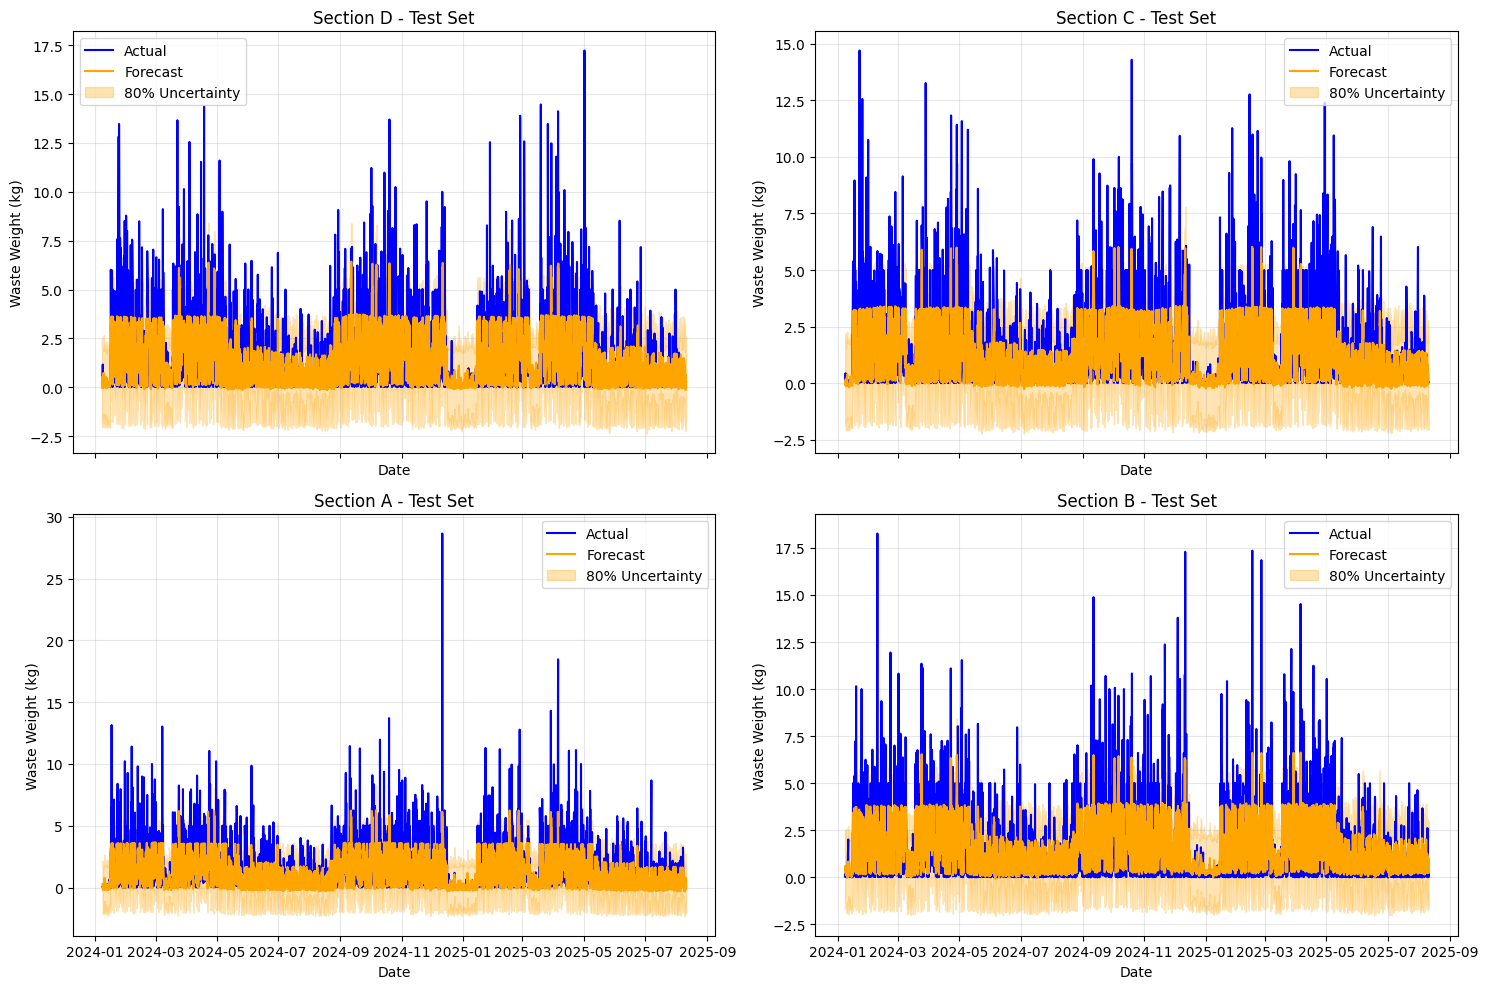

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for i, sec in enumerate(sections):
    ax = axes[i]
    test_df = test_data[sec].copy()

    # Get predictions
    future = test_df[['time_bin'] + regressor_list].rename(columns={'time_bin': 'ds'})
    forecast = models[sec].predict(future)

    # Plot actual
    ax.plot(test_df['time_bin'], test_df['Waste_Weight_kg'], 'b-', label='Actual', linewidth=1.5)
    # Plot predicted
    ax.plot(test_df['time_bin'], forecast['yhat'], 'orange', label='Forecast', linewidth=1.5)
    # Plot uncertainty interval
    ax.fill_between(test_df['time_bin'], forecast['yhat_lower'], forecast['yhat_upper'],
                     color='orange', alpha=0.3, label='80% Uncertainty')
    ax.set_title(f'Section {sec} - Test Set')
    ax.set_xlabel('Date')
    ax.set_ylabel('Waste Weight (kg)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 7‑Day Forecast for All Sections

Given a start date (or automatically from the last available date in the full dataset), we forecast the next 7 days for each section. For the regressors:
- `Foot_Traffic`: use the average of the last 7 days of available data.
- `is_holiday` and `is_special_day`: we set them to 0 for future dates (can be adjusted if we have holiday calendars).

We then plot the forecasts.

In [10]:
def get_last_week_average(section_df, regressor, days=7):
    """Return the average of the last `days` values of a regressor for a given section."""
    last_days = section_df.sort_values('time_bin').tail(days)
    return last_days[regressor].mean()

def forecast_next_7_days(section, model, full_section_data, start_date=None):
    """
    Generate a 7-day forecast for a given section starting from `start_date`.
    If start_date is None, start from the day after the last date in full_section_data.
    """
    if start_date is None:
        last_date = full_section_data['time_bin'].max()
        start_date = last_date + pd.Timedelta(days=1)

    future_dates = pd.date_range(start=start_date, periods=7, freq='D')

    # For each regressor, estimate future values
    # Here we use simple last-week average for Foot_Traffic; holidays/special days set to 0
    foot_avg = get_last_week_average(full_section_data, 'Foot_Traffic')

    future_df = pd.DataFrame({'ds': future_dates})
    future_df['Foot_Traffic'] = foot_avg
    future_df['is_holiday'] = 0
    future_df['is_special_day'] = 0

    forecast = model.predict(future_df)

    return future_dates, forecast

# Combine all data for each section (full historical)
full_data_by_section = {sec: df[df['Canteen_Section'] == sec] for sec in sections}

# Generate forecasts
forecast_7day = {}
for sec in sections:
    dates, fc = forecast_next_7_days(sec, models[sec], full_data_by_section[sec])
    forecast_7day[sec] = (dates, fc)
    print(f"\nSection {sec} 7-day forecast (starting {dates[0].date()}):")
    print(pd.DataFrame({'Date': dates, 'Forecast (kg)': fc['yhat'].values}).to_string(index=False))


Section D 7-day forecast (starting 2025-08-11):
               Date  Forecast (kg)
2025-08-11 19:00:00       0.452921
2025-08-12 19:00:00       0.400450
2025-08-13 19:00:00       0.429208
2025-08-14 19:00:00       0.395818
2025-08-15 19:00:00       0.395690
2025-08-16 19:00:00       0.296182
2025-08-17 19:00:00       0.286701

Section C 7-day forecast (starting 2025-08-11):
               Date  Forecast (kg)
2025-08-11 18:00:00       0.219841
2025-08-12 18:00:00       0.184215
2025-08-13 18:00:00       0.159999
2025-08-14 18:00:00       0.166223
2025-08-15 18:00:00       0.224149
2025-08-16 18:00:00       0.253279
2025-08-17 18:00:00       0.215108

Section A 7-day forecast (starting 2025-08-11):
               Date  Forecast (kg)
2025-08-11 19:30:00      -0.024189
2025-08-12 19:30:00       0.000234
2025-08-13 19:30:00      -0.012186
2025-08-14 19:30:00       0.024904
2025-08-15 19:30:00      -0.063024
2025-08-16 19:30:00      -0.073770
2025-08-17 19:30:00      -0.038255

Section B 7-

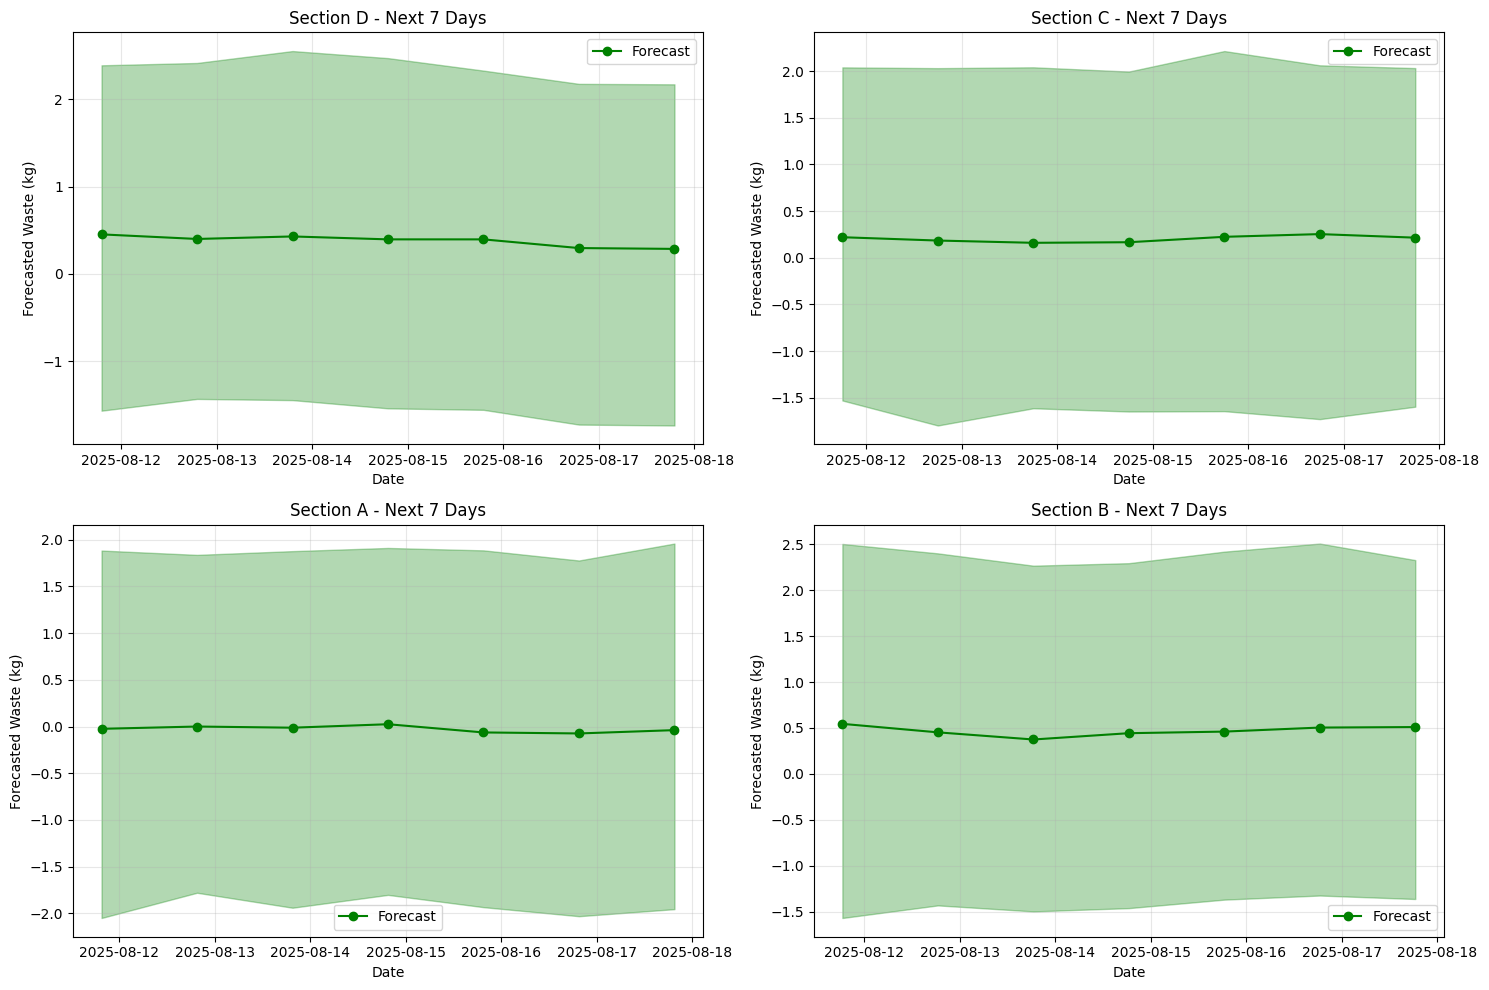

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, sec in enumerate(sections):
    ax = axes[i]
    dates, fc = forecast_7day[sec]
    ax.plot(dates, fc['yhat'], 'o-', color='green', label='Forecast')
    ax.fill_between(dates, fc['yhat_lower'], fc['yhat_upper'], alpha=0.3, color='green')
    ax.set_title(f'Section {sec} - Next 7 Days')
    ax.set_xlabel('Date')
    ax.set_ylabel('Forecasted Waste (kg)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Models

We save each trained Prophet model as a joblib file in the `models/` folder. This allows us to load them later without retraining.

In [12]:
os.makedirs('models', exist_ok=True)

for sec in sections:
    model_path = f'models/prophet_model_{sec}.joblib'
    joblib.dump(models[sec], model_path)
    print(f"Saved model for section {sec} to {model_path}")

print("\nAll models saved successfully.")

Saved model for section D to models/prophet_model_D.joblib
Saved model for section C to models/prophet_model_C.joblib
Saved model for section A to models/prophet_model_A.joblib
Saved model for section B to models/prophet_model_B.joblib

All models saved successfully.
